# Week 3 — Gaussian Properties: The Foundation of Diffusion

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Visualize** the Gaussian PDF and CDF, understanding their key features
2. **Verify** the normalizing constant computationally (∫f(x)dx = 1)
3. **Apply** linear transformations to Gaussians (the reparameterization trick!)
4. **Demonstrate** closure under addition of independent Gaussians
5. **Confirm** the 68-95-99.7 rule empirically

---

## Why This Matters for Diffusion Models

Gaussian distributions are not just mathematically convenient—they are **essential** to diffusion models:

- **Forward process**: We add Gaussian noise at each step
- **Reparameterization trick**: We sample $\epsilon \sim N(0,1)$ and transform it
- **Closure properties**: Sum of Gaussian noises is still Gaussian (enables "jumping" steps)
- **Final state**: After enough noise, any data becomes $N(0, I)$

Understanding these properties deeply will make the diffusion math feel natural.

---

## Section 0: Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy import integrate

# Reproducibility
np.random.seed(42)

# Plot style
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12

---

## Section 1: The Gaussian PDF

The probability density function (PDF) of the standard normal distribution $N(0, 1)$ is:

$$f(x) = \frac{1}{\sqrt{2\pi}} e^{-x^2/2}$$

The general Gaussian $N(\mu, \sigma^2)$ has PDF:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-(x-\mu)^2/(2\sigma^2)}$$

**Connection to notes**: See `w03_stat110_normal_dist.md` Section 6 for why $\sqrt{2\pi}$ appears.

### TODO 1.1: Plot the Standard Normal PDF

Use `scipy.stats.norm.pdf()` to plot the PDF of $N(0, 1)$ over the range $[-4, 4]$.

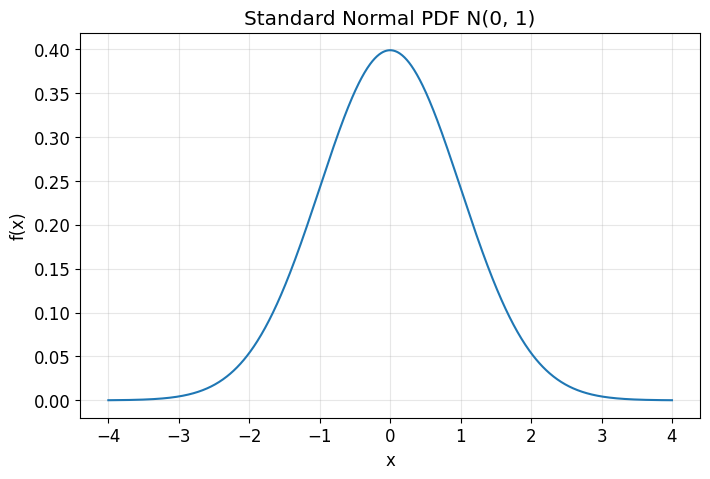

In [45]:
# TODO: Create x values from -4 to 4
# x = None  # Your code here
x = np.linspace(start=-4, stop=4, num=1000)

# TODO: Compute PDF values using scipy.stats.norm.pdf
# pdf_values = None  # Your code here
pdf_values = stats.norm.pdf(x=x, loc=0, scale=1)

# TODO: Plot the PDF
# plt.plot(...)
# plt.xlabel('x')
# plt.ylabel('f(x)')
# plt.title('Standard Normal PDF N(0, 1)')
# plt.grid(True, alpha=0.3)
# plt.show()
plt.plot(x, pdf_values)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Standard Normal PDF N(0, 1)')
plt.grid(True, alpha=0.3)
plt.show()

### TODO 1.2: Verify the Normalizing Constant

A valid PDF must integrate to 1. Use `scipy.integrate.quad` to verify:

$$\int_{-\infty}^{\infty} \frac{1}{\sqrt{2\pi}} e^{-x^2/2} dx = 1$$

In [9]:
# TODO: Define the PDF function
def standard_normal_pdf(x):
    """Standard normal PDF."""
    exponent = (-x ** 2) / 2
    numerator = np.exp(exponent)
    denominator = np.sqrt(2 * np.pi)
    return numerator / denominator

# TODO: Integrate from -inf to inf using scipy.integrate.quad
# Hint: Use np.inf for infinity
# result, error = integrate.quad(...)
result, error = integrate.quad(standard_normal_pdf, -np.inf, np.inf)

print(f"Integral of N(0,1) PDF: {result:.10f}")
print(f"Error estimate: {error:.2e}")

Integral of N(0,1) PDF: 1.0000000000
Error estimate: 1.02e-08


In [8]:
# ═══════════════════════════════════════════════════════════════
# CHECKPOINT 1: Verify your integral is correct
# ═══════════════════════════════════════════════════════════════
result, _ = integrate.quad(standard_normal_pdf, -np.inf, np.inf)
assert abs(result - 1.0) < 1e-8, f"Expected 1.0, got {result}"
print("✓ Checkpoint 1 passed: PDF integrates to 1")

✓ Checkpoint 1 passed: PDF integrates to 1


---

## Section 2: The CDF and Φ Notation

The cumulative distribution function (CDF) of the standard normal is denoted $\Phi(z)$:

$$\Phi(z) = P(Z \leq z) = \int_{-\infty}^{z} \frac{1}{\sqrt{2\pi}} e^{-t^2/2} dt$$

**Key property (symmetry)**: $\Phi(-z) = 1 - \Phi(z)$

**Connection to notes**: See `w03_stat110_normal_dist.md` Section 9.

### TODO 2.1: Plot the CDF Φ(z)

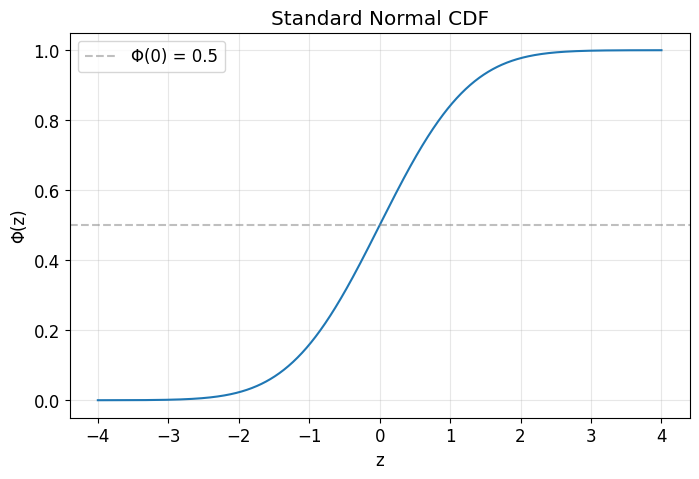

In [17]:
# TODO: Create z values from -4 to 4
# z = None  # Your code here
z = np.linspace(start=-4, stop=4, num=1000)

# TODO: Compute CDF values using scipy.stats.norm.cdf
# cdf_values = None  # Your code here
cdf_values = stats.norm.cdf(x=z, loc=0, scale=1)

# TODO: Plot the CDF
# plt.plot(...)
# plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Φ(0) = 0.5')
# plt.xlabel('z')
# plt.ylabel('Φ(z)')
# plt.title('Standard Normal CDF')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()
plt.plot(z, cdf_values)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Φ(0) = 0.5')
plt.xlabel('z')
plt.ylabel('Φ(z)')
plt.title('Standard Normal CDF')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### TODO 2.2: Verify the Symmetry Property

Check that $\Phi(-z) = 1 - \Phi(z)$ for several values of $z$.

In [18]:
# TODO: Test symmetry for z = 0.5, 1.0, 1.5, 2.0
test_z_values = [0.5, 1.0, 1.5, 2.0]

print("Verifying Φ(-z) = 1 - Φ(z):")
print("-" * 50)

for z in test_z_values:
    # TODO: Compute Φ(-z) and 1 - Φ(z)
    # phi_neg_z = None  # Your code here
    # one_minus_phi_z = None  # Your code here
    phi_neg_z = stats.norm.cdf(x=-z) 
    one_minus_phi_z = 1 - stats.norm.cdf(x=z)
    
    # print(f"z = {z}: Φ(-z) = {phi_neg_z:.6f}, 1 - Φ(z) = {one_minus_phi_z:.6f}")
    print(f"z = {z}: Φ(-z) = {phi_neg_z:.6f}, 1 - Φ(z) = {one_minus_phi_z:.6f}")

Verifying Φ(-z) = 1 - Φ(z):
--------------------------------------------------
z = 0.5: Φ(-z) = 0.308538, 1 - Φ(z) = 0.308538
z = 1.0: Φ(-z) = 0.158655, 1 - Φ(z) = 0.158655
z = 1.5: Φ(-z) = 0.066807, 1 - Φ(z) = 0.066807
z = 2.0: Φ(-z) = 0.022750, 1 - Φ(z) = 0.022750


In [19]:
# ═══════════════════════════════════════════════════════════════
# CHECKPOINT 2: Verify symmetry property
# ═══════════════════════════════════════════════════════════════
for z in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    phi_neg_z = stats.norm.cdf(-z)
    one_minus_phi_z = 1 - stats.norm.cdf(z)
    assert abs(phi_neg_z - one_minus_phi_z) < 1e-10, f"Symmetry failed for z={z}"
print("✓ Checkpoint 2 passed: Symmetry Φ(-z) = 1 - Φ(z) verified")

✓ Checkpoint 2 passed: Symmetry Φ(-z) = 1 - Φ(z) verified


---

## Section 3: Closure Under Linear Transformation

**This is critical for diffusion models!**

If $Z \sim N(0, 1)$, then for any constants $\mu$ and $\sigma > 0$:

$$X = \mu + \sigma Z \sim N(\mu, \sigma^2)$$

### The Reparameterization Trick

Instead of sampling $X \sim N(\mu, \sigma^2)$ directly, we:
1. Sample $\epsilon \sim N(0, 1)$ (standard normal)
2. Compute $X = \mu + \sigma \epsilon$

**Why this matters for diffusion**:
- In the forward process: $x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$
- The model predicts $\epsilon$, not $x_{t-1}$ directly

**Connection to notes**: See `w03_stat110_normal_dist.md` Section 10.

### TODO 3.1: Verify Linear Transformation

Sample $Z \sim N(0, 1)$, transform to $X = 2 + 1.5Z$, and verify $X \sim N(2, 2.25)$.

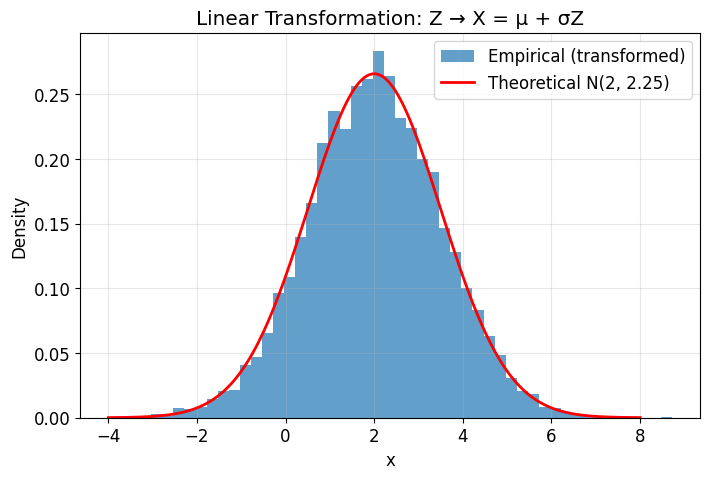

Empirical mean: 2.0203 (theoretical: 2)
Empirical variance: 2.2543 (theoretical: 2.25)


In [21]:
# Parameters
mu = 2
sigma = 1.5
n_samples = 10000

# TODO: Sample Z from N(0, 1)
# Z = None  # Your code here
Z = np.random.normal(loc=0, scale=1, size=n_samples) # Your code here

# TODO: Transform to X = mu + sigma * Z
# X = None  # Your code here
X = mu + sigma * Z # Your code here

# TODO: Create histogram of X and overlay theoretical N(mu, sigma^2) PDF
x_range = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
theoretical_pdf = stats.norm.pdf(x_range, loc=mu, scale=sigma)

plt.hist(X, bins=50, density=True, alpha=0.7, label='Empirical (transformed)')
plt.plot(x_range, theoretical_pdf, 'r-', linewidth=2, label=f'Theoretical N({mu}, {sigma**2})')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Linear Transformation: Z → X = μ + σZ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# TODO: Print empirical mean and variance
print(f"Empirical mean: {X.mean():.4f} (theoretical: {mu})")
print(f"Empirical variance: {X.var():.4f} (theoretical: {sigma**2})")

In [22]:
# ═══════════════════════════════════════════════════════════════
# CHECKPOINT 3: Verify linear transformation
# ═══════════════════════════════════════════════════════════════
Z = np.random.randn(100000)
X = 2 + 1.5 * Z
assert abs(X.mean() - 2) < 0.05, f"Mean should be ~2, got {X.mean():.4f}"
assert abs(X.var() - 2.25) < 0.1, f"Variance should be ~2.25, got {X.var():.4f}"
print("✓ Checkpoint 3 passed: Linear transformation produces correct distribution")

✓ Checkpoint 3 passed: Linear transformation produces correct distribution


---

## Section 4: Sum of Independent Gaussians

If $X \sim N(\mu_X, \sigma_X^2)$ and $Y \sim N(\mu_Y, \sigma_Y^2)$ are **independent**, then:

$$X + Y \sim N(\mu_X + \mu_Y, \sigma_X^2 + \sigma_Y^2)$$

**Why this matters for diffusion**:
- Forward process adds noise multiple times: $x_t = x_{t-1} + \text{noise}$
- Because of this property, we can "jump" from $x_0$ to $x_t$ in one step!
- The total noise variance is the sum of individual variances

### TODO 4.1: Verify Sum of Independent Gaussians

Let $X \sim N(1, 0.25)$ (i.e., $\mu_X=1$, $\sigma_X=0.5$) and $Y \sim N(2, 0.64)$ (i.e., $\mu_Y=2$, $\sigma_Y=0.8$).

Then $X + Y$ should be $\sim N(3, 0.89)$.

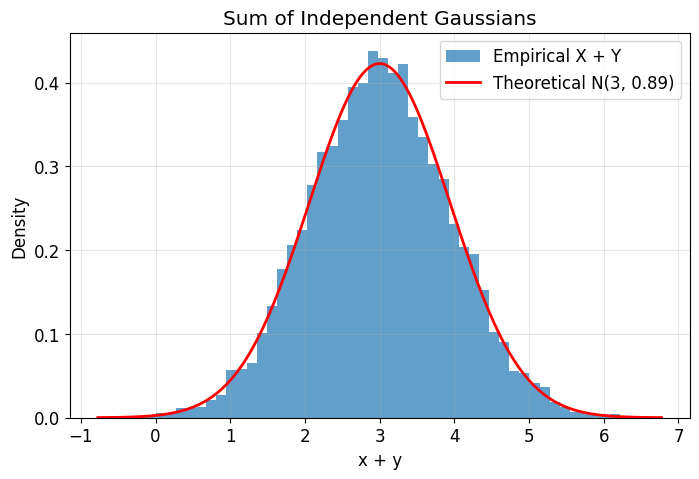

Empirical mean of X+Y: 3.0013 (theoretical: 3)
Empirical variance of X+Y: 0.8907 (theoretical: 0.89)


In [23]:
# Parameters
mu_X, sigma_X = 1, 0.5
mu_Y, sigma_Y = 2, 0.8
n_samples = 10000

# TODO: Sample X and Y independently
# X = None  # Your code here: np.random.normal(mu_X, sigma_X, n_samples)
# Y = None  # Your code here
X = np.random.normal(loc=mu_X, scale=sigma_X, size=n_samples) # Your code here: np.random.normal(mu_X, sigma_X, n_samples)
Y = np.random.normal(loc=mu_Y, scale=sigma_Y, size=n_samples)  # Your code here

# TODO: Compute the sum
# S = None  # Your code here
S = X + Y # Your code here

# Theoretical parameters for X + Y
mu_sum = mu_X + mu_Y  # = 3
var_sum = sigma_X**2 + sigma_Y**2  # = 0.25 + 0.64 = 0.89
sigma_sum = np.sqrt(var_sum)

# TODO: Plot histogram of S and overlay theoretical PDF
s_range = np.linspace(mu_sum - 4*sigma_sum, mu_sum + 4*sigma_sum, 200)
theoretical_pdf = stats.norm.pdf(s_range, loc=mu_sum, scale=sigma_sum)

plt.hist(S, bins=50, density=True, alpha=0.7, label='Empirical X + Y')
plt.plot(s_range, theoretical_pdf, 'r-', linewidth=2, label=f'Theoretical N({mu_sum}, {var_sum:.2f})')
plt.xlabel('x + y')
plt.ylabel('Density')
plt.title('Sum of Independent Gaussians')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Empirical mean of X+Y: {S.mean():.4f} (theoretical: {mu_sum})")
print(f"Empirical variance of X+Y: {S.var():.4f} (theoretical: {var_sum:.2f})")

In [24]:
# ═══════════════════════════════════════════════════════════════
# CHECKPOINT 4: Verify sum of independent Gaussians
# ═══════════════════════════════════════════════════════════════
X = np.random.normal(1, 0.5, 100000)
Y = np.random.normal(2, 0.8, 100000)
S = X + Y
assert abs(S.mean() - 3) < 0.05, f"Mean should be ~3, got {S.mean():.4f}"
assert abs(S.var() - 0.89) < 0.05, f"Variance should be ~0.89, got {S.var():.4f}"
print("✓ Checkpoint 4 passed: Sum of Gaussians has correct distribution")

✓ Checkpoint 4 passed: Sum of Gaussians has correct distribution


---

## Section 5: The 68-95-99.7 Rule

For any normal distribution $N(\mu, \sigma^2)$:

| Range | Probability |
|-------|-------------|
| $\mu \pm 1\sigma$ | 68.27% |
| $\mu \pm 2\sigma$ | 95.45% |
| $\mu \pm 3\sigma$ | 99.73% |

This rule helps us understand how "spread out" Gaussian samples are.

### TODO 5.1: Visualize the Regions

Shade the ±1σ, ±2σ, and ±3σ regions on the PDF.

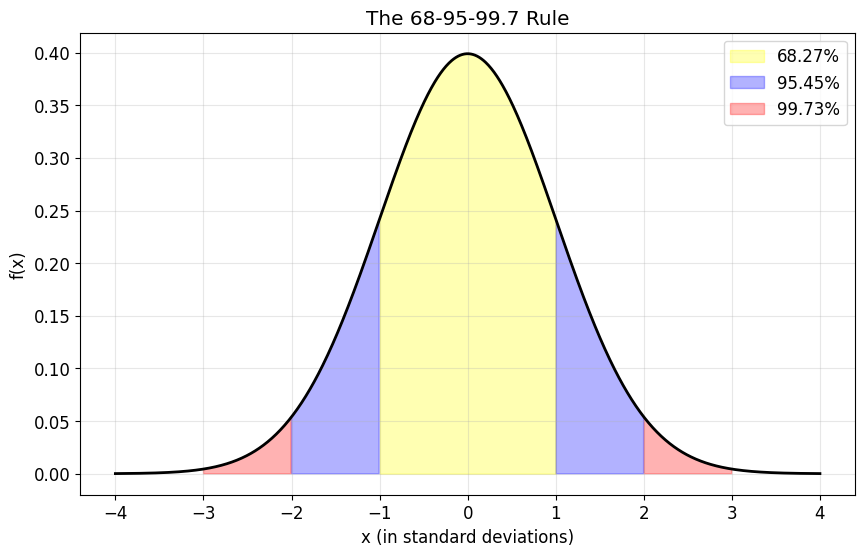

In [34]:
# TODO: Create the visualization
x = np.linspace(-4, 4, 1000)
pdf = stats.norm.pdf(x)

plt.figure(figsize=(10, 6))
plt.plot(x, pdf, 'k-', linewidth=2)

# TODO: Fill regions with different colors
# Hint: Use plt.fill_between(x, pdf, where=condition, alpha=0.3, color='...', label='...')
# Region 1: |x| < 1 (68.27%)
# Region 2: 1 <= |x| < 2 (additional 27.18%)
# Region 3: 2 <= |x| < 3 (additional 4.28%)
plt.fill_between(x=x, y1=pdf, where=np.abs(x) < 1, alpha=0.3, color='yellow', label='68.27%')
plt.fill_between(x=x, y1=pdf, where=(np.abs(x) < 2) & (np.abs(x) >= 1), alpha=0.3, color='blue', label='95.45%')
plt.fill_between(x=x, y1=pdf, where=(np.abs(x) < 3) & (np.abs(x) >= 2), alpha=0.3, color='red', label='99.73%')

plt.xlabel('x (in standard deviations)')
plt.ylabel('f(x)')
plt.title('The 68-95-99.7 Rule')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### TODO 5.2: Verify Empirically

Sample 10,000 points from $N(0, 1)$ and compute what fraction falls in each region.

In [43]:
n_samples = 10000
samples = np.random.randn(n_samples)

# TODO: Compute empirical percentages
# within_1sigma = None  # Fraction of samples with |x| < 1
# within_2sigma = None  # Fraction of samples with |x| < 2
# within_3sigma = None  # Fraction of samples with |x| < 3
within_1sigma = (np.abs(samples) < 1).mean() # Fraction of samples with |x| < 1
within_2sigma = (np.abs(samples) < 2).mean() # Fraction of samples with |x| < 2
within_3sigma = (np.abs(samples) < 3).mean()  # Fraction of samples with |x| < 3

# Theoretical values
theory_1sigma = 0.6827
theory_2sigma = 0.9545
theory_3sigma = 0.9973

print("68-95-99.7 Rule Verification:")
print("-" * 50)
print(f"Within ±1σ: {within_1sigma:.4f} (theoretical: {theory_1sigma})")
print(f"Within ±2σ: {within_2sigma:.4f} (theoretical: {theory_2sigma})")
print(f"Within ±3σ: {within_3sigma:.4f} (theoretical: {theory_3sigma})")

68-95-99.7 Rule Verification:
--------------------------------------------------
Within ±1σ: 0.6746 (theoretical: 0.6827)
Within ±2σ: 0.9495 (theoretical: 0.9545)
Within ±3σ: 0.9966 (theoretical: 0.9973)


In [44]:
# ═══════════════════════════════════════════════════════════════
# CHECKPOINT 5: Verify 68-95-99.7 rule
# ═══════════════════════════════════════════════════════════════
samples = np.random.randn(100000)
within_1sigma = np.mean(np.abs(samples) < 1)
within_2sigma = np.mean(np.abs(samples) < 2)
within_3sigma = np.mean(np.abs(samples) < 3)

assert abs(within_1sigma - 0.6827) < 0.02, f"1σ: expected ~0.6827, got {within_1sigma:.4f}"
assert abs(within_2sigma - 0.9545) < 0.01, f"2σ: expected ~0.9545, got {within_2sigma:.4f}"
assert abs(within_3sigma - 0.9973) < 0.005, f"3σ: expected ~0.9973, got {within_3sigma:.4f}"
print("✓ Checkpoint 5 passed: 68-95-99.7 rule verified")

✓ Checkpoint 5 passed: 68-95-99.7 rule verified


---

## Section 6: Key Takeaways

### Summary of Gaussian Properties

| Property | Statement | Diffusion Relevance |
|----------|-----------|---------------------|
| **Normalization** | $\int f(x)dx = 1$ | Valid probability distribution |
| **Symmetry** | $\Phi(-z) = 1 - \Phi(z)$ | Symmetric noise |
| **Linear Transform** | $\mu + \sigma Z \sim N(\mu, \sigma^2)$ | Reparameterization trick |
| **Additive Closure** | $X + Y \sim N(\mu_X + \mu_Y, \sigma_X^2 + \sigma_Y^2)$ | Forward process "jumping" |

### Connection to Diffusion Models

These properties make Gaussians the **backbone of diffusion models**:

1. **Reparameterization**: We sample $\epsilon \sim N(0,1)$ and transform it to get any Gaussian
2. **Additive closure**: We can skip intermediate steps in the forward process
3. **Known PDF**: We can compute log-likelihoods analytically
4. **Score function**: The gradient of log-density has a simple form (see `w03_score_of_gaussian.md`)

---

## Done!

### Week 3 Artifacts

- ✅ `notebooks/w03_gaussian_properties.ipynb` — This notebook
- 📝 `notes/w03_score_of_gaussian.md` — Score function of Gaussian (diffusion contact)
- 📝 `notes/w03_stat110_normal_dist.md` — Stat110 normal distribution notes

### Next Steps

1. Complete the diffusion contact in `w03_score_of_gaussian.md`
2. Derive the score function by hand
3. Visualize how the score "points toward the mean"